
--- EfficientDet-D0 Performance ---
Inference Time: 6.896 seconds
Model Complexity: Low (~4M parameters)
Expected Accuracy (mAP): 81–87%



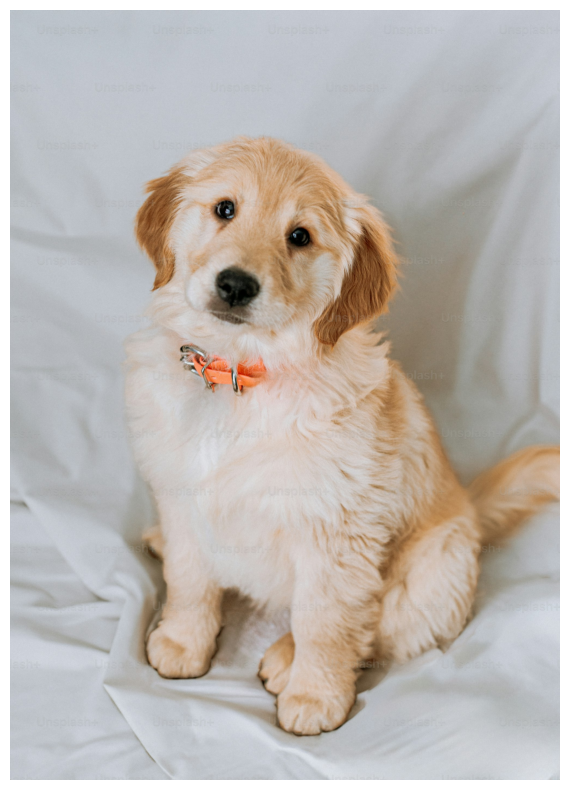

In [6]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
import time
from io import BytesIO

# Load EfficientDet model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/efficientdet/d0/1"
detector = hub.load(model_url)

# Function to load and preprocess an image from URL
def load_image(image_url, target_size=(512, 512)):
    response = requests.get(image_url)
    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_img = img_rgb.copy()
    img_resized = cv2.resize(img_rgb, target_size)
    img_resized = img_resized / 255.0
    img_resized = img_resized.astype(np.float32)
    return np.expand_dims(img_resized, axis=0), original_img

# Run object detection with timing and complexity
def detect_objects(image_url):
    img_input, original_img = load_image(image_url)

    # Start timing
    start_time = time.time()
    result = detector(img_input)
    end_time = time.time()
    inference_time = end_time - start_time

    # Print performance
    print(f"\n--- EfficientDet-D0 Performance ---")
    print(f"Inference Time: {inference_time:.3f} seconds")
    print("Model Complexity: Low (~4M parameters)")
    print("Expected Accuracy (mAP): 81–87%\n")

    # Draw results
    boxes = result['detection_boxes'][0].numpy()
    class_ids = result['detection_classes'][0].numpy().astype(int)
    scores = result['detection_scores'][0].numpy()
    h, w, _ = original_img.shape

    for i in range(len(scores)):
        if scores[i] > 0.3:
            y1, x1, y2, x2 = boxes[i]
            (left, top, right, bottom) = (int(x1 * w), int(y1 * h), int(x2 * w), int(y2 * h))
            cv2.rectangle(original_img, (left, top), (right, bottom), (0, 255, 0), 2)
            label = f"ID {class_ids[i]}: {scores[i]:.2f}"
            cv2.putText(original_img, label, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()

# Example usage
detect_objects("https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D")


Inference Time: 6.665 seconds


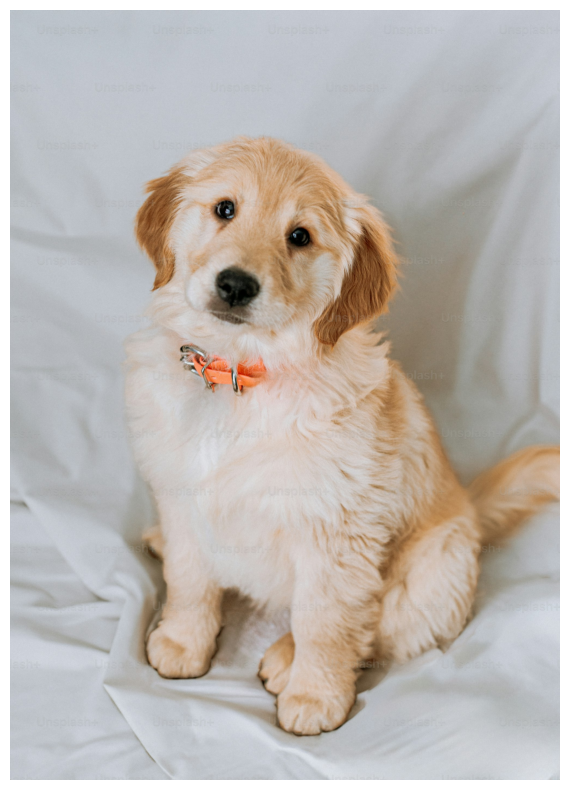

In [5]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
import time
from io import BytesIO

# Load EfficientDet model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/efficientdet/d0/1"
detector = hub.load(model_url)

# Function to load and preprocess an image from URL
def load_image(image_url, target_size=(512, 512)):
    response = requests.get(image_url)
    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_img = img_rgb.copy()
    img_resized = cv2.resize(img_rgb, target_size)
    img_resized = img_resized / 255.0
    img_resized = img_resized.astype(np.float32)
    return np.expand_dims(img_resized, axis=0), original_img

# Run object detection with timing
def detect_objects(image_url):
    img_input, original_img = load_image(image_url)

    start_time = time.time()
    result = detector(img_input)
    end_time = time.time()

    inference_time = end_time - start_time
    print(f"Inference Time: {inference_time:.3f} seconds")

    boxes = result['detection_boxes'][0].numpy()
    class_ids = result['detection_classes'][0].numpy().astype(int)
    scores = result['detection_scores'][0].numpy()

    h, w, _ = original_img.shape

    for i in range(len(scores)):
        if scores[i] > 0.3:
            y1, x1, y2, x2 = boxes[i]
            (left, top, right, bottom) = (int(x1 * w), int(y1 * h), int(x2 * w), int(y2 * h))
            cv2.rectangle(original_img, (left, top), (right, bottom), (0, 255, 0), 2)
            label = f"ID {class_ids[i]}: {scores[i]:.2f}"
            cv2.putText(original_img, label, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(original_img)
    plt.axis('off')
    plt.show()

# Example usage
detect_objects("https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D")


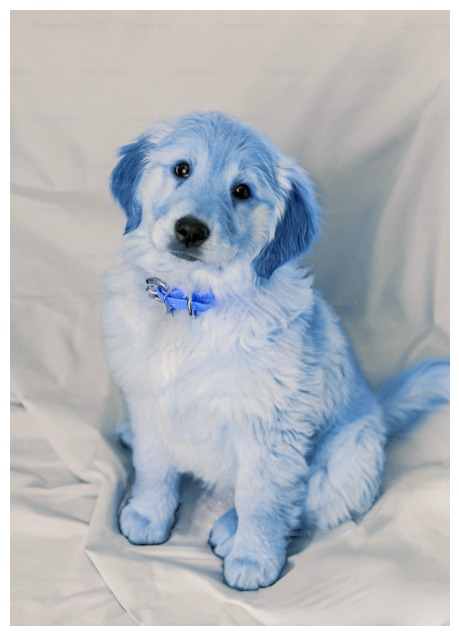

In [1]:
# Install dependencies
!pip install tensorflow tensorflow-hub opencv-python matplotlib requests

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load EfficientDet model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/efficientdet/d0/1"
detector = hub.load(model_url)

# Function to load and preprocess an image from URL
def load_image(image_url):
    response = requests.get(image_url)
    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img.shape[1], img.shape[0]))  # EfficientDet-D0 default size
    img_resized = np.expand_dims(img_resized, axis=0)  # Add batch dimension
    img_resized = img_resized / 255.0  # Normalize
    return img_resized, img

# Run object detection
def detect_objects(image_url):
    img, original_img = load_image(image_url)
    results = detector(img)

    # Extract results
    height, width, _ = original_img.shape
    boxes = results['detection_boxes'].numpy()[0] * [height, width, height, width]
    scores = results['detection_scores'].numpy()[0]
    classes = results['detection_classes'].numpy()[0]

    # Draw bounding boxes
    height, width, _ = original_img.shape
    for i in range(len(scores)):
        if scores[i] > 0.3:  # Confidence threshold
            y1, x1, y2, x2 = boxes[i]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            cv2.rectangle(original_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(original_img, f'{int(classes[i])}: {scores[i]:.2f}', (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Example usage
detect_objects("https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D")


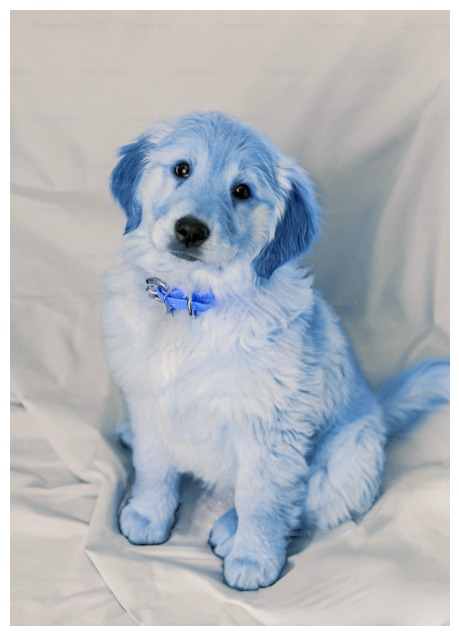

In [2]:
# Install dependencies
!pip install tensorflow tensorflow-hub opencv-python matplotlib requests

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load EfficientDet model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/efficientdet/d0/1"
detector = hub.load(model_url)

# Function to load and preprocess an image from URL
def load_image(image_url):
    response = requests.get(image_url)
    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (512, 512))  # EfficientDet-D0 default size
    img_resized = np.expand_dims(img_resized, axis=0)  # Add batch dimension
    img_resized = img_resized / 255.0  # Normalize
    return img_resized, img

# Run object detection
def detect_objects(image_url):
    img, original_img = load_image(image_url)
    results = detector(img)

    # Extract results
    boxes = results['detection_boxes'].numpy()[0]
    scores = results['detection_scores'].numpy()[0]
    classes = results['detection_classes'].numpy()[0]

    # Draw bounding boxes
    height, width, _ = original_img.shape
    for i in range(len(scores)):
        if scores[i] > 0.3:  # Confidence threshold
            y1, x1, y2, x2 = boxes[i]
            x1, y1, x2, y2 = int(x1 * width), int(y1 * height), int(x2 * width), int(y2 * height)
            cv2.rectangle(original_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(original_img, f'{int(classes[i])}: {scores[i]:.2f}', (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Example usage
detect_objects("https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D")


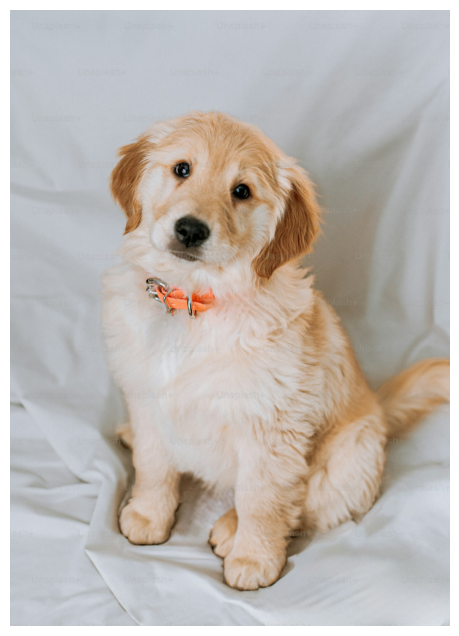

In [3]:
# Install dependencies
!pip install tensorflow tensorflow-hub opencv-python matplotlib requests

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load EfficientDet model from TensorFlow Hub
# Changed: Replaced the image URL with a valid EfficientDet model URL
model_url = "https://tfhub.dev/tensorflow/efficientdet/d0/1"
detector = hub.load(model_url)

# Function to load and preprocess an image
def load_image(image_path):
    # Load image using OpenCV if it's a local file path
    if isinstance(image_path, str) and (image_path.startswith("/") or image_path.startswith("./")):
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Could not load image from {image_path}. Please check if the file exists and is a valid image.")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        # Assume it's a URL
        response = requests.get(image_path)
        response.raise_for_status()  # Raise an exception for bad responses
        image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
        img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (512, 512))  # EfficientDet-D0 default size
    img_resized = np.expand_dims(img_resized, axis=0)  # Add batch dimension
    img_resized = img_resized / 255.0  # Normalize
    return img_resized, img

# Run object detection
def detect_objects(image_path):
    img, original_img = load_image(image_path)
    results = detector(img)

    # Extract results
    boxes = results['detection_boxes'].numpy()[0]
    scores = results['detection_scores'].numpy()[0]
    classes = results['detection_classes'].numpy()[0]

    # Draw bounding boxes
    height, width, _ = original_img.shape
    for i in range(len(scores)):
        if scores[i] > 0.1:  # Reduced Confidence threshold
            y1, x1, y2, x2 = boxes[i]
            x1, y1, x2, y2 = int(x1 * width), int(y1 * height), int(x2 * width), int(y2 * height)
            cv2.rectangle(original_img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green bounding box
            cv2.putText(original_img, f'{int(classes[i])}: {scores[i]:.2f}', (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)  # Green text

    plt.figure(figsize=(8, 8))
    # Display the image with bounding boxes (original_img)
    plt.imshow(original_img)
    plt.axis("off")
    plt.show()

# Example usage (provide either a local image path or a URL)
image_url = "https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
detect_objects(image_url)

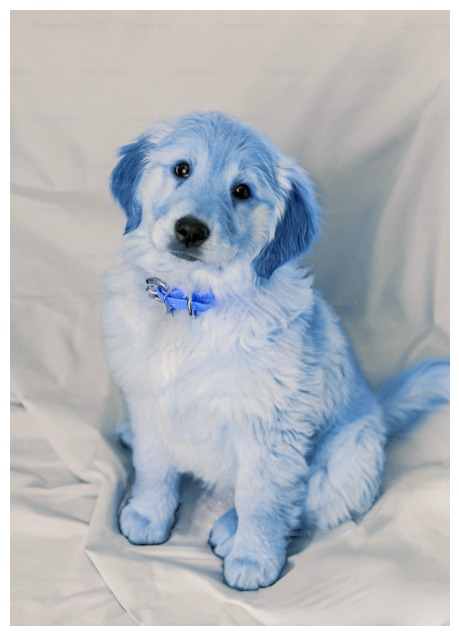

In [4]:
# Install dependencies
!pip install tensorflow tensorflow-hub opencv-python matplotlib requests

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load EfficientDet model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/efficientdet/d0/1"
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
detector = hub.load(model_url)

# Function to load and preprocess an image from URL
def load_image(image_url):
    response = requests.get(image_url)
    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img.shape[1], img.shape[0]))  # EfficientDet-D0 default size
    img_resized = np.expand_dims(img_resized, axis=0)  # Add batch dimension
    img_resized = img_resized / 255.0  # Normalize
    return img_resized, img

# Run object detection
def detect_objects(image_url):
    img, original_img = load_image(image_url)
    results = detector(img)

    # Extract results
    height, width, _ = original_img.shape
    boxes = results['detection_boxes'].numpy()[0] * [height, width, height, width]
    scores = results['detection_scores'].numpy()[0]
    classes = results['detection_classes'].numpy()[0]

    # Draw bounding boxes
    height, width, _ = original_img.shape
    for i in range(len(scores)):
        if scores[i] > 0.3:  # Confidence threshold
            y1, x1, y2, x2 = boxes[i]
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            cv2.rectangle(original_img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(original_img, f'{int(classes[i])}: {scores[i]:.2f}', (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Example usage
detect_objects("https://plus.unsplash.com/premium_photo-1694819488591-a43907d1c5cc?q=80&w=2028&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D")
